In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/NF-UNSW-NB15-v3.csv")

In [3]:
temporal_features = [
    "FLOW_DURATION_MILLISECONDS",
    "SRC_TO_DST_IAT_MIN",
    "SRC_TO_DST_IAT_MAX",
    "SRC_TO_DST_IAT_AVG",
    "SRC_TO_DST_IAT_STDDEV", 
    "DST_TO_SRC_IAT_MIN",
    "DST_TO_SRC_IAT_MAX",
    "DST_TO_SRC_IAT_AVG",
    "DST_TO_SRC_IAT_STDDEV"
]

In [4]:
df_temporal = df[temporal_features + ["Attack"]]
df_temporal = df_temporal.dropna()

print(df_temporal.head())
print(df_temporal['Attack'].value_counts())

   FLOW_DURATION_MILLISECONDS  SRC_TO_DST_IAT_MIN  SRC_TO_DST_IAT_MAX  \
0                           2                   0                   0   
1                         335                   0                  91   
2                        2460                   0                1843   
3                           1                   0                   0   
4                           1                   0                   0   

   SRC_TO_DST_IAT_AVG  SRC_TO_DST_IAT_STDDEV  DST_TO_SRC_IAT_MIN  \
0                   0                      0                   0   
1                  12                     19                   0   
2                  10                    119                   0   
3                   0                      0                   0   
4                   0                      0                   0   

   DST_TO_SRC_IAT_MAX  DST_TO_SRC_IAT_AVG  DST_TO_SRC_IAT_STDDEV  Attack  
0                   0                   0                      0  Benign  
1 

In [5]:
X = df_temporal[temporal_features]
y = df_temporal["Attack"]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
clf = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced', 
    random_state=42
)
clf.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [12]:
y_pred = clf.predict(X_test_scaled)

In [13]:
from sklearn.metrics import classification_report, accuracy_score

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8807761818700657
                precision    recall  f1-score   support

      Analysis       0.03      0.83      0.06       245
      Backdoor       0.03      0.11      0.04       932
        Benign       1.00      0.91      0.95    447546
           DoS       0.03      0.22      0.06      1196
      Exploits       0.18      0.22      0.20      8550
       Fuzzers       0.31      0.28      0.29      6763
       Generic       0.13      0.76      0.21      3930
Reconnaissance       0.47      0.22      0.30      3415
     Shellcode       0.08      0.25      0.12       476
         Worms       0.00      0.31      0.01        32

      accuracy                           0.88    473085
     macro avg       0.23      0.41      0.23    473085
  weighted avg       0.96      0.88      0.91    473085



In [ ]:
import numpy as np

In [16]:
classes = np.unique(y_test)

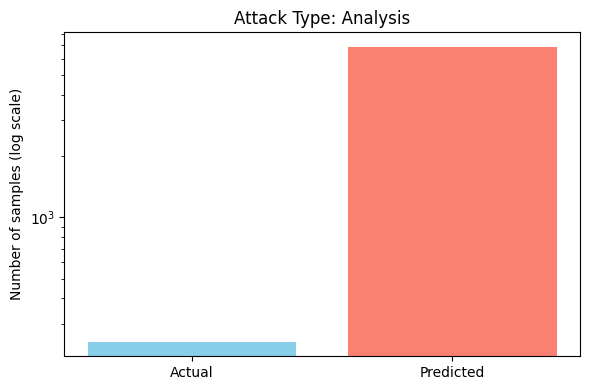

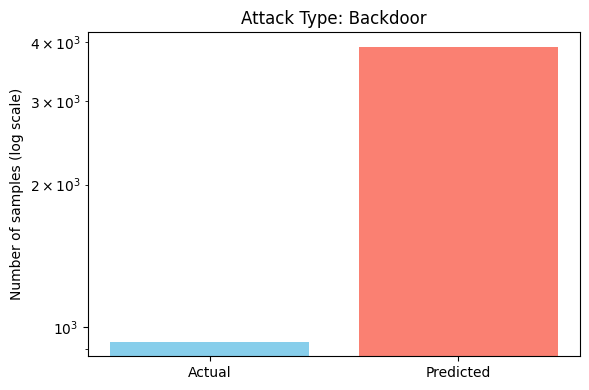

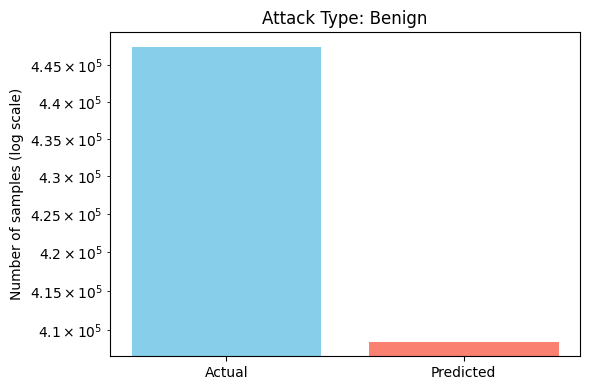

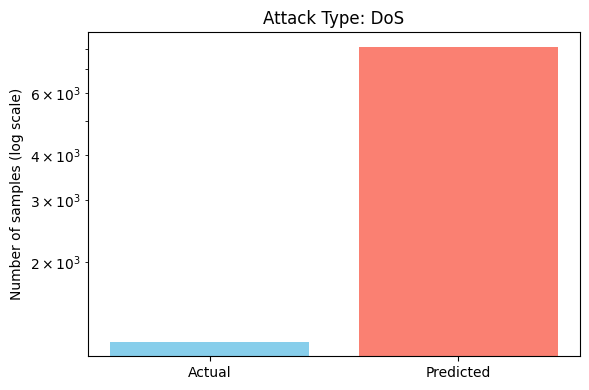

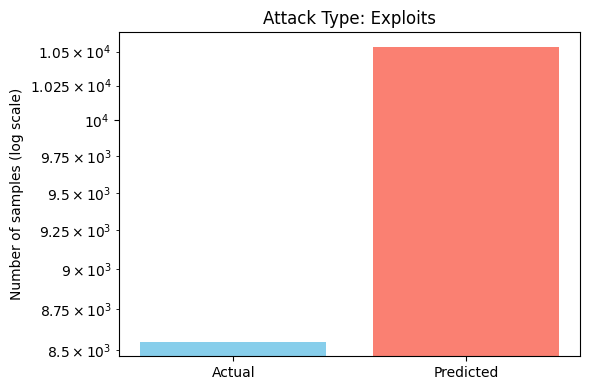

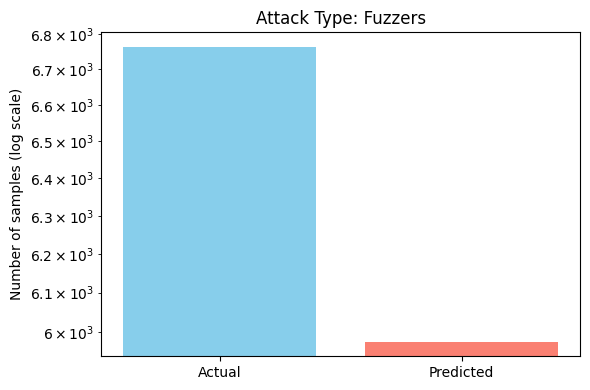

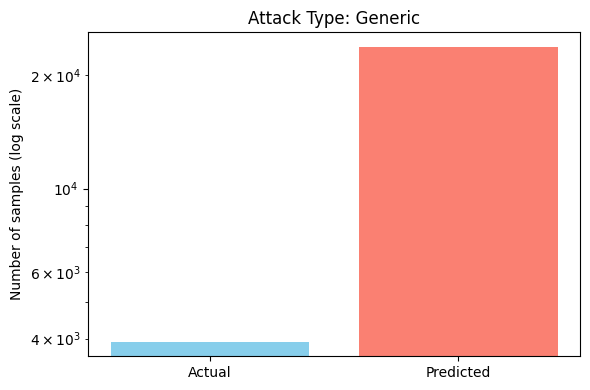

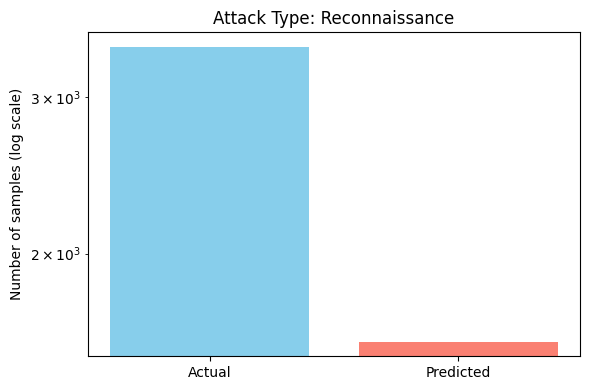

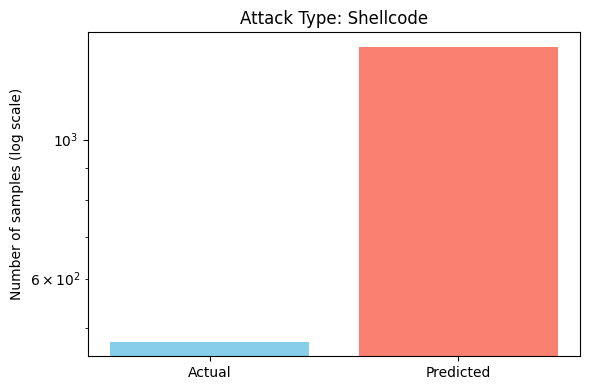

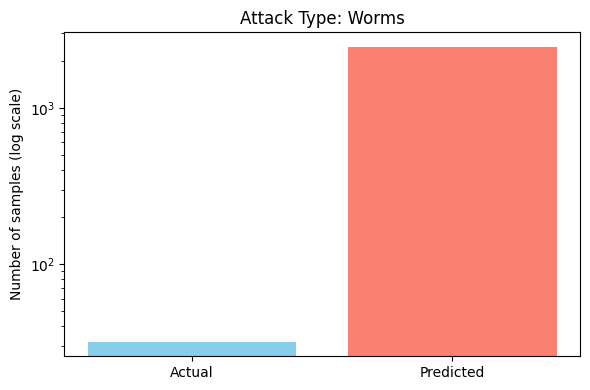

In [17]:
import matplotlib.pyplot as plt

for attack in classes:
    actual_count = np.sum(y_test == attack)
    pred_count = np.sum(y_pred == attack)
    
    plt.figure(figsize=(6,4))
    plt.bar(['Actual', 'Predicted'], [actual_count, pred_count], color=['skyblue','salmon'])
    
    plt.yscale('log')
    plt.ylabel('Number of samples (log scale)')
    plt.title(f'Attack Type: {attack}')
    plt.tight_layout()
    plt.show()